# Lifelines Modelling
This notebook builds and evaluates survival models to predict when customers are likely to place their next order. It starts with data loading and preprocessing, fits a Cox proportional hazards model, checks model assumptions, and then compares alternative accelerated failure time (AFT) models.

In [15]:
import numpy as np
import pandas as pd

from sme_kt_zh_collaboration_forecasting import modelling as sm
from sme_kt_zh_collaboration_forecasting import utils as su

from lifelines import CoxPHFitter
from lifelines import LogNormalAFTFitter
from lifelines import WeibullAFTFitter

## Prepare the Input Data
The raw sales data is loaded and deduplicated here. This creates a clean event history that can safely be used for train-test splitting and survival-data construction.

In [16]:
df = su.read_sales_data()
len_b = len(df)
df = df.drop_duplicates()
len_a = len(df)

print(f"Dropped {len_b-len_a} duplicates.")

Dropped 12 duplicates.


## Build, Fit, and Rank with the Cox Model
This block engineers the prior-order feature, creates the shared train-test split used throughout the notebook, prepares the censored survival dataset, and fits the Cox proportional hazards model with the same covariates later used in the AFT models. The ranking outputs here are stored in reusable variables so the final comparison against Weibull and log-normal AFT is apples to apples.

In [17]:
# 0. Ensure consistent ordering and num_prior_orders across the whole history
df = df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["customer", "date"])
df["num_prior_orders"] = df.groupby("customer").cumcount()

# 1. Split Raw Data
CUTOFF = "2024-12-31"
TOP_K = 50
df_train_raw, df_test_raw = sm.create_test_train(df, CUTOFF)

# 2. Initial Filtering
# We filter for >3 orders IN TRAIN to ensure we have enough history to model
df_train_raw = sm.filter_for_n_orders(df_train_raw, n=3)
train_customers = df_train_raw["customer"].unique()
df_test_raw = df_test_raw[df_test_raw["customer"].isin(train_customers)].copy()

# 3. Prepare Training Data for Cox
# This applies the censoring logic so the model knows who is currently 'silent'
train_final = sm.prepare_data(df_train_raw, CUTOFF)

# 4. Fit the Model
# We use num_prior_orders as a proxy for 'loyalty' / frequency
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    train_final,
    duration_col="duration",
    event_col="event",
    cluster_col="customer",
    strata=["customer_cat"],
    formula="num_prior_orders"
 )

cph.print_summary()

# 5. Prepare Test Data
test_final = sm.prepare_data(df_test_raw, CUTOFF)

# 6. Priority list evaluation on test
prio = sm.predicted_vs_real_priorities(cph, test_final, customer_col="customer")
cox_ranking_summary = sm.summarize_top_k_predictions(prio, top_k=TOP_K)

print(
    f"Within the top {TOP_K}, {cox_ranking_summary['correct_predictions']} customers are in both lists."
)
print(f"Recall@{TOP_K}:    {cox_ranking_summary['recall_at_k']:.2%}")

model,lifelines.CoxPHFitter
duration col,'duration'
event col,'event'
cluster col,'customer'
penalizer,0.1
l1 ratio,0.0
robust variance,True
strata,customer_cat
baseline estimation,breslow
number of observations,9325
number of events observed,9035


Within the top 50, 31 customers are in both lists.
Recall@50:    62.00%


## Check Cox Assumptions
After fitting the Cox model, this section runs diagnostic checks for the proportional hazards assumptions. The output helps determine whether the chosen features and stratification are compatible with the model assumptions.


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.2685)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4298)'>]]

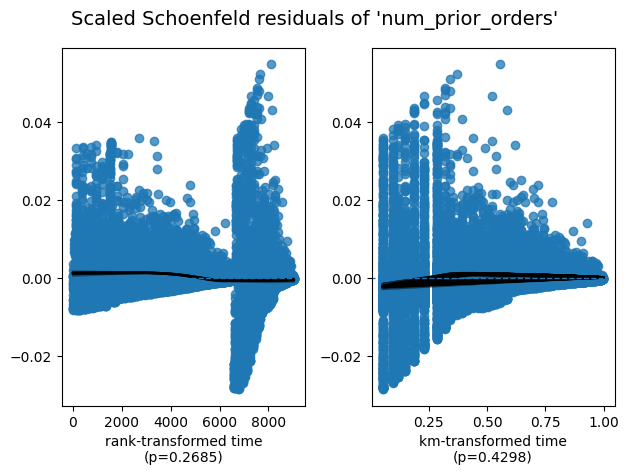

In [18]:
cph.check_assumptions(train_final, p_value_threshold=0.05, show_plots=True)

## Evaluate Cox Performance
This section computes concordance metrics for the Cox model on the same test cohort used by both AFT models. Together with the stored top-k ranking metrics, these values feed directly into the final comparison table.

In [19]:
# Concordance evaluation on the shared test set. We calculate two test scores because we want to make sure it is correct.
cox_c_index_score = sm.c_index_on_test_via_score(cph, test_final)
cox_c_index_manual = sm.c_index_on_test_manual(cph, test_final)
cox_comparison_row = sm.comparison_row(
    model_name="Cox PH",
    c_index=cox_c_index_score,
    ranking_summary=cox_ranking_summary,
)

print("Test C-index (CoxPH, score): ", cox_c_index_score)
print("Test C-index (CoxPH, manual):", cox_c_index_manual)

Test C-index (CoxPH, score):  0.6902796126696509
Test C-index (CoxPH, manual): 0.6902796126696509


/Users/oliver_sdsc/Documents/KT_ZH_SME/sme-kt-zh-collaboration-forecasting/.venv/lib/python3.11/site-packages/lifelines/utils/__init__.py:933: UserWarning: DataFrame Index is not unique, defaulting to incrementing index instead.
  warnings.warn("DataFrame Index is not unique, defaulting to incrementing index instead.")


## Compare Weibull and Log-Normal AFT Variants
This section reuses the same training cohort, test cohort, covariates, penalization level, and evaluation metrics used for the Cox model. That keeps the Weibull, log-normal, and Cox results directly comparable across concordance and top-k ranking quality.

In [20]:
# ======================== WEIBULL AFT ========================
weibull_aft = WeibullAFTFitter(penalizer=0.1)
weibull_aft.fit(
    train_final,
    duration_col="duration",
    event_col="event",
    formula="num_prior_orders + customer_cat"
 )

weibull_aft.print_summary()

prio_weibull = sm.predicted_vs_real_priorities_aft(
    weibull_aft,
    test_final,
    customer_col="customer",
)
weibull_ranking_summary = sm.summarize_top_k_predictions(
    prio_weibull,
    top_k=TOP_K,
 )
weibull_c_index = sm.c_index_on_test_via_score(weibull_aft, test_final)
weibull_comparison_row = sm.comparison_row(
    model_name="Weibull AFT",
    c_index=weibull_c_index,
    ranking_summary=weibull_ranking_summary,
)

print(
    f"[Weibull AFT] Within the top {TOP_K}, "
    f"{weibull_ranking_summary['correct_predictions']} customers are in both lists."
)
print(f"[Weibull AFT] Recall@{TOP_K}:    {weibull_ranking_summary['recall_at_k']:.2%}")
print("Test C-index (Weibull AFT):", weibull_c_index)

# ======================== LOG-NORMAL AFT ========================
lognorm_aft = LogNormalAFTFitter(penalizer=0.1)
lognorm_aft.fit(
    train_final,
    duration_col="duration",
    event_col="event",
    formula="num_prior_orders + customer_cat"
 )

lognorm_aft.print_summary()

prio_lognorm = sm.predicted_vs_real_priorities_aft(
    lognorm_aft,
    test_final,
    customer_col="customer",
)
lognorm_ranking_summary = sm.summarize_top_k_predictions(
    prio_lognorm,
    top_k=TOP_K,
 )
lognorm_c_index = sm.c_index_on_test_via_score(lognorm_aft, test_final)
lognorm_comparison_row = sm.comparison_row(
    model_name="Log-Normal AFT",
    c_index=lognorm_c_index,
    ranking_summary=lognorm_ranking_summary,
)

print(
    f"[Log-Normal AFT] Within the top {TOP_K}, "
    f"{lognorm_ranking_summary['correct_predictions']} customers are in both lists."
)
print(f"[Log-Normal AFT] Recall@{TOP_K}:    {lognorm_ranking_summary['recall_at_k']:.2%}")
print("Test C-index (Log-Normal AFT):", lognorm_c_index)

/Users/oliver_sdsc/Documents/KT_ZH_SME/sme-kt-zh-collaboration-forecasting/.venv/lib/python3.11/site-packages/autograd/tracer.py:54: RuntimeWarning: overflow encountered in matmul
  return f_raw(*args, **kwargs)


<lifelines.WeibullAFTFitter: fitted with 9325 total observations, 290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 9325
number of events observed = 9035
           log-likelihood = -43273.09
         time fit was run = 2026-03-13 10:23:55 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                              
lambda_ Intercept              4.03     56.10      0.02            3.99            4.06               54.19               58.08
        num_prior_orders      -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
        customer_cat[T.cat_2]  1.84      6.29      0.17            1.51            2.17                4.51                8.78
        customer_cat[T.cat_3]  0.17      1.18      0.03            0.11            0.23                1.12                1.26
        customer_cat[T.cat_5]  1.60      4.95      0.14            1.32            1.88                3.74                6.55
        customer_cat[T.cat_7]  1.92      6.84      0.73            0.48            3.36                1.62               28.89
        customer_cat[T.cat_8]  1.86      6.41      0.74            0.41            3.30                1.51               27.20
rho_    Intercept             -0.29      0.75      0.01           -0.30           -0.27                0.74                0.76

                               cmp to      z      p  -log2(p)
param   covariate                                            
lambda_ Intercept                0.00 228.04 <0.005       inf
        num_prior_orders         0.00 -53.64 <0.005       inf
        customer_cat[T.cat_2]    0.00  10.80 <0.005     87.86
        customer_cat[T.cat_3]    0.00   5.58 <0.005     25.29
        customer_cat[T.cat_5]    0.00  11.18 <0.005     93.91
        customer_cat[T.cat_7]    0.00   2.62   0.01      6.81
        customer_cat[T.cat_8]    0.00   2.52   0.01      6.40
rho_    Intercept                0.00 -39.18 <0.005       inf
---
Concordance = 0.67
AIC = 86562.17
log-likelihood ratio test = 1925.46 on 6 df
-log2(p) of ll-ratio test = inf

[Weibull AFT] Within the top 50, 32 customers are in both lists.
[Weibull AFT] Recall@50:    64.00%
Test C-index (Weibull AFT): 0.6923216857876483


<lifelines.LogNormalAFTFitter: fitted with 9325 total observations, 290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 9325
number of events observed = 9035
           log-likelihood = -42542.89
         time fit was run = 2026-03-13 10:23:55 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
mu_    Intercept              3.31     27.37      0.02            3.27            3.34               26.42               28.36
       num_prior_orders      -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
       customer_cat[T.cat_2]  1.80      6.02      0.18            1.44            2.15                4.24                8.57
       customer_cat[T.cat_3] -0.01      0.99      0.03           -0.07            0.05                0.93                1.05
       customer_cat[T.cat_5]  1.69      5.42      0.15            1.39            1.99                4.03                7.31
       customer_cat[T.cat_7]  2.21      9.11      0.75            0.73            3.69                2.08               39.86
       customer_cat[T.cat_8]  0.88      2.42      0.74           -0.56            2.33                0.57               10.29
sigma_ Intercept              0.32      1.37      0.01            0.30            0.33                1.35                1.39

                              cmp to      z      p  -log2(p)
param  covariate                                            
mu_    Intercept                0.00 183.68 <0.005       inf
       num_prior_orders         0.00 -38.48 <0.005       inf
       customer_cat[T.cat_2]    0.00  10.00 <0.005     75.73
       customer_cat[T.cat_3]    0.00  -0.41   0.68      0.55
       customer_cat[T.cat_5]    0.00  11.14 <0.005     93.29
       customer_cat[T.cat_7]    0.00   2.93 <0.005      8.23
       customer_cat[T.cat_8]    0.00   1.20   0.23      2.11
sigma_ Intercept                0.00  43.95 <0.005       inf
---
Concordance = 0.68
AIC = 85101.78
log-likelihood ratio test = 1507.55 on 6 df
-log2(p) of ll-ratio test = inf

[Log-Normal AFT] Within the top 50, 31 customers are in both lists.
[Log-Normal AFT] Recall@50:    62.00%
Test C-index (Log-Normal AFT): 0.6899120544194965


We look at recall since we are only interested in a list of customers who will order in a certain intervall. We are not actually interested in the absolute order of the priority list. Recall tells us how many of the top k have been correctly included in the top k.

In [21]:
comparison_df = pd.DataFrame(
    [
        cox_comparison_row,
        weibull_comparison_row,
        lognorm_comparison_row,
    ]
)
comparison_df[["c_index", "recall_at_k"]] = comparison_df[[
    "c_index",
    "recall_at_k",
]].round(4)

comparison_df

,model,c_index,top_k,correct_predictions,recall_at_k
0,Cox PH,0.6903,50,31,0.62
1,Weibull AFT,0.6923,50,32,0.64
2,Log-Normal AFT,0.6899,50,31,0.62
